# 02. COE Forecasting

This follows the population work in `01. Population Modelling and Forecasting`. The end goal is to forecast Category A COE premiums (the price of a car ownership certificate) and to test whether two outside variables help: the resident population, which we have already forecasted, and the COE quota, which the government sets and provides future values of ([LTA Release COE data](https://www.lta.gov.sg/content/dam/ltagov/news/press/2026/260424-coe-quota.pdf)). As explained before, this acts as our "demand and supply" variables to support my intuitive story. The method for combining them is a dynamic regression, that is a regression with ARIMA errors, following Forecasting: Principles and Practice (FPP), chapter 10.

## 1. Methodology and Setup

We forecast the Category A COE premium. Category A covers mainstream cars of engine capacity upto 1600cc which is our usual sedan. Hence, it is the category most tied to ordinary resident car demand, which is why it is the one we pair with resident population.

Methodology:

1. Treat the premium as a univariate series first, run the same checks and tests we used for population, ACF and PACF, ADF and KPSS, and differencing, and fit ARIMA and ETS as baselines.
2. Then build a dynamic regression, premium against resident population and quota, with ARIMA errors, and see whether either regressor earns its place by removing them one at a time.
3. Judge whether the regressors help in forecasting or underperform against the univariate series.
4. Select a model, forecast, and provide final review.

### Considerations

Before researching for this project, I assumed that COE biddings happen annually or at least every 6 months. However, COE bidding happens twice a month, so the premium and quota are biweekly, running from 2010. Resident population is annual which encounters scaling issues. To use it as a regressor we interpolate the annual figures onto the biweekly bidding dates by slicing the years to biweekly. 
Initially we thought about using arima models to splice the biweekly value but it does not work the same as linear regression as ARIMA 
is not continuous but rather follows discrete steps, so it canot forecast the inbetween values. We resort to splicing the actual resident 
value by 24 while acknowledging it as an actual limitation to our invetigation.

In [1]:
import sys
import warnings

import numpy as np
import pandas as pd

import matplotlib
matplotlib.rcParams['font.family'] = 'AppleGothic'
matplotlib.rcParams['font.size'] = 15
matplotlib.rcParams['axes.unicode_minus'] = False
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.exponential_smoothing.ets import ETSModel
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

sys.path.append('src')
from stationarity_diagnostics import plot_acf_diagnostics, stationarity_test

## 2. Data Cleaning

The COE file has one row per bidding exercise per vehicle class, with the quota and the premium. We take Category A data up to 2025 so that the resident data, which we have until 2025, covers the whole window. Each exercise is given a fractional year time stamp so the two bidding rounds in a month sit in the right order, and the annual resident population is interpolated onto those time stamps. Singapore government calculates population value of the given year until end June. So we take COE data up until 2025 bidding round 2 of June. This conveniently gives us 24 datapoints for Out of Sample test that we left out. (end June 2025 ~ end June 2026)

In [2]:
df = pd.read_csv('data/COEBiddingResultsPrices.csv')
df

,month,bidding_no,vehicle_class,quota,bids_success,bids_received,premium
0,2010-01,1,Category A,1152,1145,1342,18502
1,2010-01,1,Category B,687,679,883,19190
2,2010-01,1,Category C,173,173,265,19001
3,2010-01,1,Category D,373,365,509,889
4,2010-01,1,Category E,586,567,1011,19889
...,...,...,...,...,...,...,...
1945,2026-06,2,Category A,1251,"1,245","1,768",123847
1946,2026-06,2,Category B,883,879,"1,202",123502
1947,2026-06,2,Category C,291,280,390,93001
1948,2026-06,2,Category D,532,494,615,9989


Some bids have commas for values in thousands so we need to clean these. We only need Category A data of quota and premium. The date is in year-month format so we will create separate columns to handle them individually.

In [3]:
for col in ['quota', 'premium', 'bids_success', 'bids_received']:
    df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', ''), errors='coerce')
    
cat_a = df[df['vehicle_class'] == 'Category A'].copy()

cat_a['year'] = cat_a['month'].str[:4].astype(int)
cat_a['mon']  = cat_a['month'].str[5:7].astype(int)
coe = cat_a[(cat_a['year'] < 2025) | ((cat_a['year'] == 2025) & (cat_a['mon'] <= 6))].copy()
coe

,month,bidding_no,vehicle_class,quota,bids_success,bids_received,premium,year,mon
0,2010-01,1,Category A,1152,1145,1342,18502,2010,1
5,2010-01,2,Category A,1151,1149,1673,20501,2010,1
10,2010-02,1,Category A,1154,1153,1326,19989,2010,2
15,2010-02,2,Category A,1148,1148,1493,20340,2010,2
20,2010-03,1,Category A,1148,1141,1758,20802,2010,3
...,...,...,...,...,...,...,...,...,...
1805,2025-04,2,Category A,1139,1124,2121,99500,2025,4
1810,2025-05,1,Category A,1267,1244,2240,103009,2025,5
1815,2025-05,2,Category A,1267,1265,1915,102501,2025,5
1820,2025-06,1,Category A,1275,1274,1691,96999,2025,6


The biddings rounds for COE typically occur on first and third Monday of the months and closes on the respective Wednesdays. Since the exact dates will follow the actual calender date and subject to changes depending on holidays and events, we will be assigning 3 and 17 respectively for bidding 1 and 2 for convenience.

In [4]:
coe['t'] = (coe['year'] + (coe['mon'] - 1) / 12 + (coe['bidding_no'] - 1) / 24).copy() # subsequent bidding rounds adds 1/24, converting to base 10.
coe = coe.sort_values('t').reset_index(drop=True)
coe['date'] = pd.to_datetime(dict(year=coe['year'], month=coe['mon'],
                                day=np.where(coe['bidding_no'] == 1, 3, 17)))

pop_df = pd.read_csv('data/IndicatorsOnPopulationAnnual.csv')

long_df = pop_df.melt(id_vars=["DataSeries"], var_name="Year", value_name="Value")
long_df["Year"] = long_df["Year"].astype(int)                        
long_df["Value"] = pd.to_numeric(long_df["Value"], errors="coerce")  # non-numeric entries -> NaN
res = long_df[long_df['DataSeries'] == 'Resident Population'].dropna().sort_values('Year')
coe['resident'] = np.interp(coe['t'], res['Year'] + 0.5, res['Value']) #joining year values of resident to June on coe data.
c = coe[['date', 'quota', 'resident', 'premium', 'bids_received', 'bids_success']]
c.tail()

,date,quota,resident,premium,bids_received,bids_success
361,2025-04-17,1139,4.199589e+06,99500,2121,1124
362,2025-05-03,1267,4.200574e+06,103009,2240,1244
363,2025-05-17,1267,4.201559e+06,102501,1915,1265
364,2025-06-03,1275,4.202544e+06,96999,1691,1274
365,2025-06-17,1254,4.203530e+06,98124,1647,1253


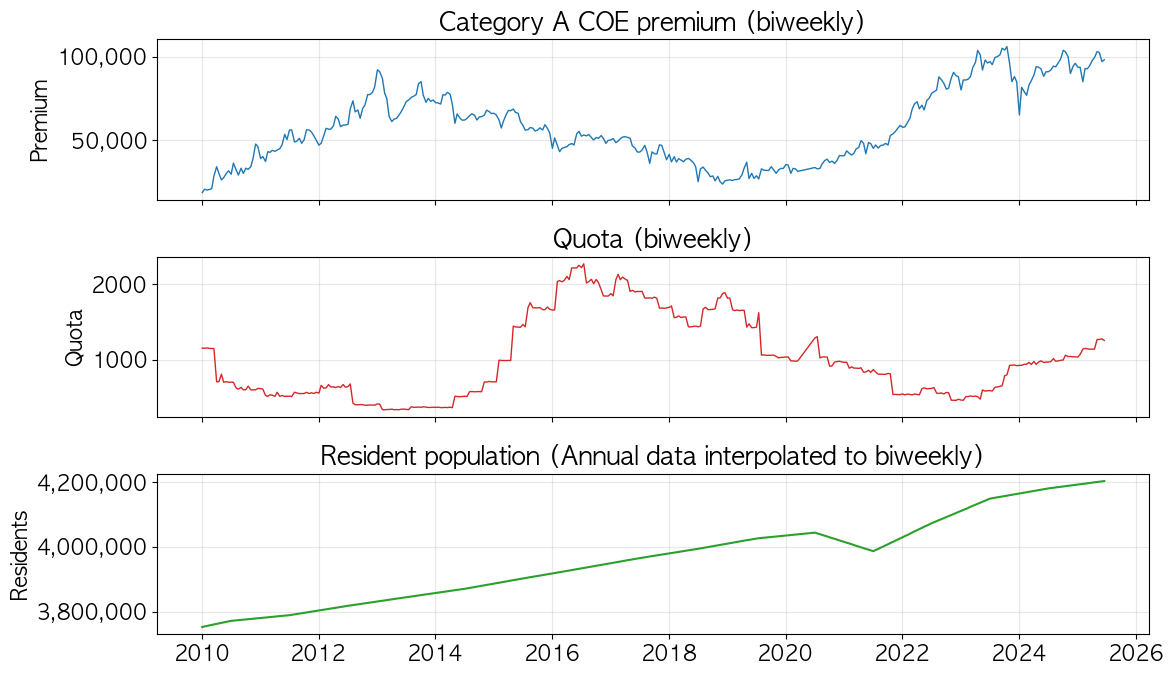

In [5]:
fig_ts, axes_ts = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
axes_ts[0].plot(c['date'], c['premium'], color='tab:blue', linewidth=1)
axes_ts[0].set_ylabel('Premium'); axes_ts[0].set_title('Category A COE premium (biweekly)')
axes_ts[0].yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
axes_ts[1].plot(c['date'], c['quota'], color='tab:red', linewidth=1)
axes_ts[1].set_ylabel('Quota'); axes_ts[1].set_title('Quota (biweekly)')
axes_ts[2].plot(c['date'], c['resident'], color='tab:green', linewidth=1.5)
axes_ts[2].set_ylabel('Residents'); axes_ts[2].set_title('Resident population (Annual data interpolated to biweekly)')
axes_ts[2].yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
for ax_ts in axes_ts:
    ax_ts.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The premium chart shows a rough trend that collapes from 2013 then rises back up in 2020. As with population model, there appears to be no evident seasonality in premium growth. As premium decreases, we observe that Quota increases at around the same time and vice versa for when coe increases. This seems to support our intuitive story on markets dynamics: as supply increases, price decreases. While we will test this effect, this shows that having quota in our model might help us explain the dip and lead to a more robust model.

As expected, resident population is a smooth trend up due to the biweekly splitting. While COE has an overall upward trend, it is less obvious to see whether population supports our demand side story: Population increases, total demand for car increases and therefore price increases.

## 3. Stationarity diagnostics

Same checks as notebook 01. We use regression='ct' for the levels because the premium clearly trends, and regression='c' for the difference, following the rule that a trend in the level becomes a constant mean in the difference and test it with ADF/KPSS tests.

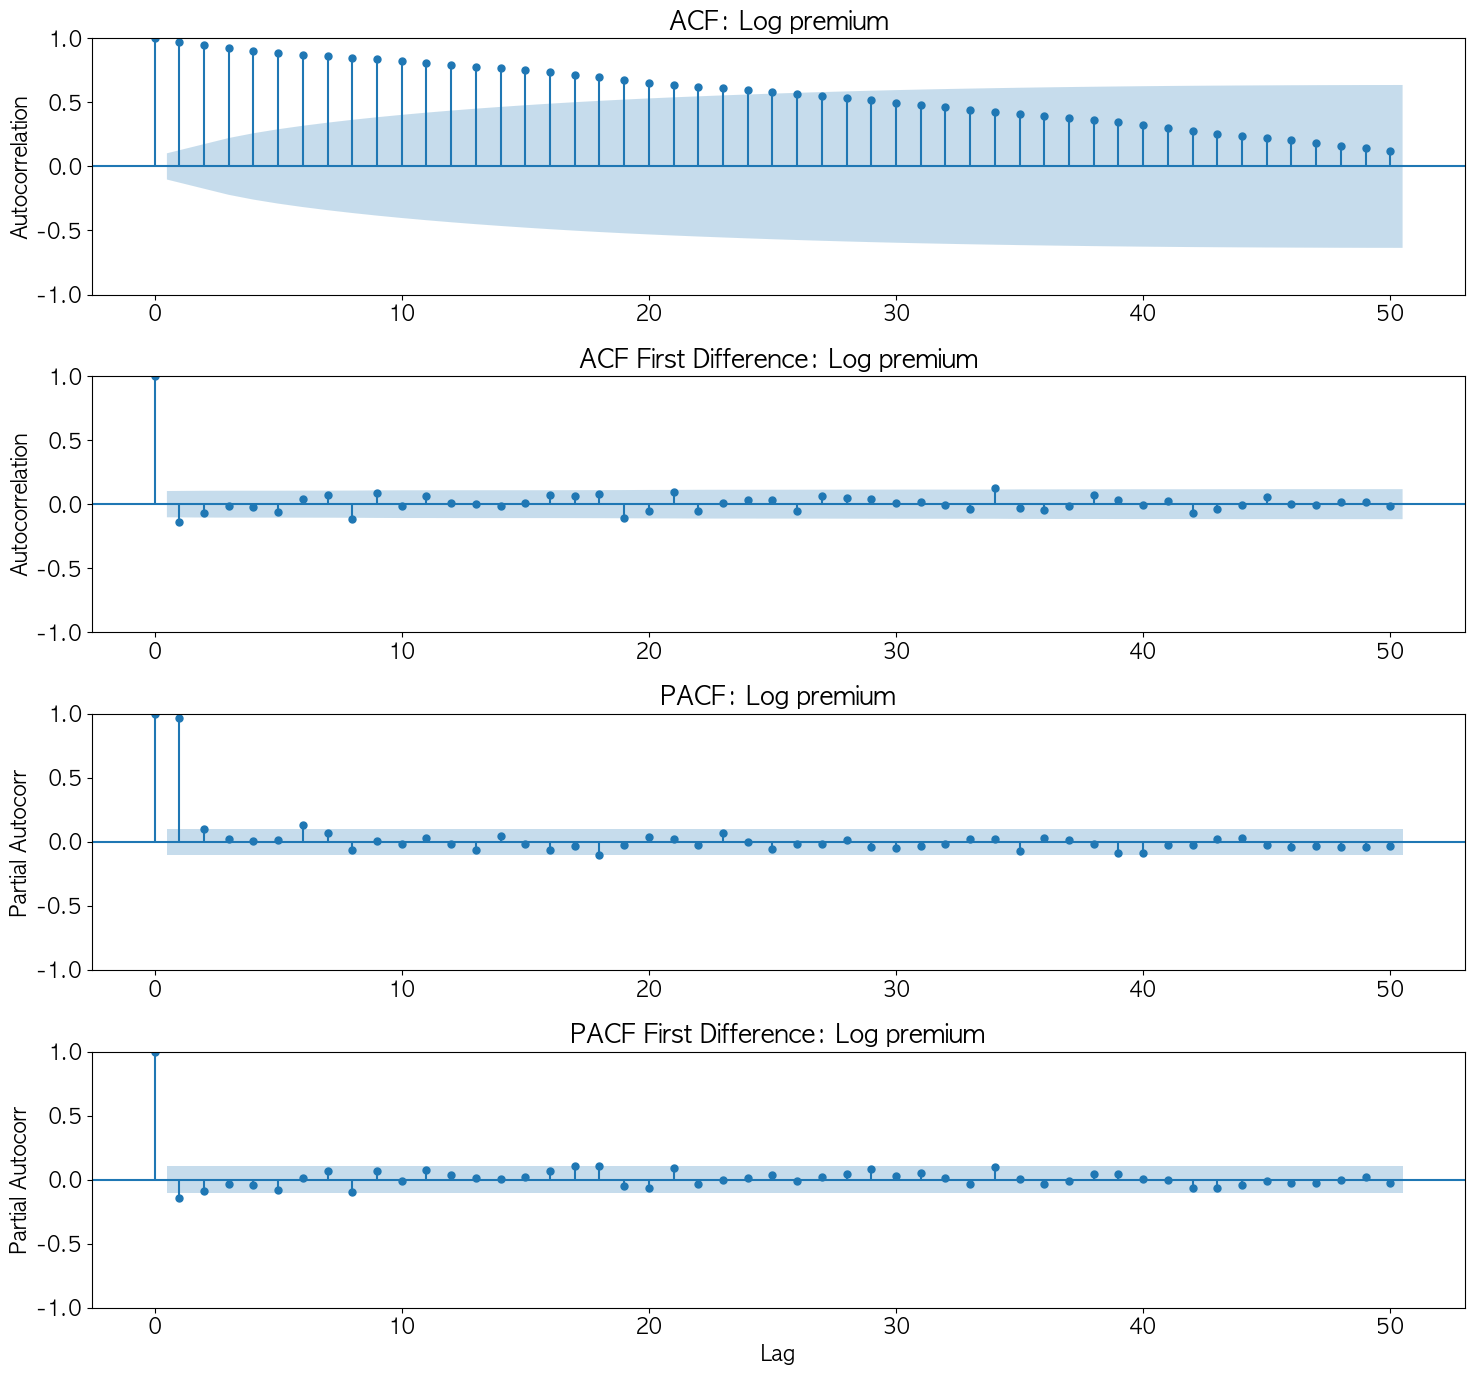

In [6]:
y = np.log(c['premium'].values)
dy = np.diff(y)
ddy = np.diff(dy)

plot_acf_diagnostics(y, 'Log premium', lags=50, figsize = (15,14))

In [7]:
warnings.filterwarnings('ignore', message = r'the test statistic')
stationarity_test(y, "Log premium", 'ct')
stationarity_test(dy, "Log premium", 'c')

--- Log premium (n=366) ---
  ADF:  stat= -2.1050  p=0.5433  FAIL TO REJECT (unit root)
  KPSS: stat=  0.4258  p=0.0100  REJECT H0 (non-stationary)
  => ✗ NON-STATIONARY (both tests agree)

--- Log premium (n=365) ---
  ADF:  stat= -7.7131  p=0.0000  REJECT H0 (stationary)
  KPSS: stat=  0.2806  p=0.1000  FAIL TO REJECT (stationary)
  => ✓ STATIONARY (both tests agree)



The levels are non stationary, both tests agree, and the log premium ACF decays slowly with a single near one spike in the PACF, the familiar unit root trend like chapter 1. So we difference once. Again, the plots show no signs of seasonality.

The first difference is stationary on ADF and KPSS tests. The correlogram of the difference is nearly flat, showing that d = 1 should be used. There are small negative spikes at lag one of ACF and PACF of the difference, just outside the band, and most of the consecutive lags sit within the tight band. This sugegsts an AR(1) and MA(1) model. So the univariate premium model is ARIMA model of the form (p, 1, q) with p and q at one. But since ACF and PACF values do not provide definte answers, we will again use differnt variations of p and q and compare the results.

>The error message is again shown as p-value falls outside the Statsmodel libraries' test statistics value. So the actual p-value is unlikely to be actually 0 but rather it falls on the extreme left tail of test statitics. 

## 4. Univariate ARIMA and ETS

We hold out the last 24 exercises from 2025 June, and fit a small ARIMA grid with drift plus the two ETS trend models. In this case, train-test split is not neccessary as we already left out the holdout value to match our population value. Again, the same 3 tests as chapter 1 will be used to select the models.

What we do need to consider is whether to add deterministic trend or not to our d = 1 ARIMA models. First, we check whether there is a non-zero mean to our differenced data. From observation, the differenced plot appears to be stationary around zero mean.

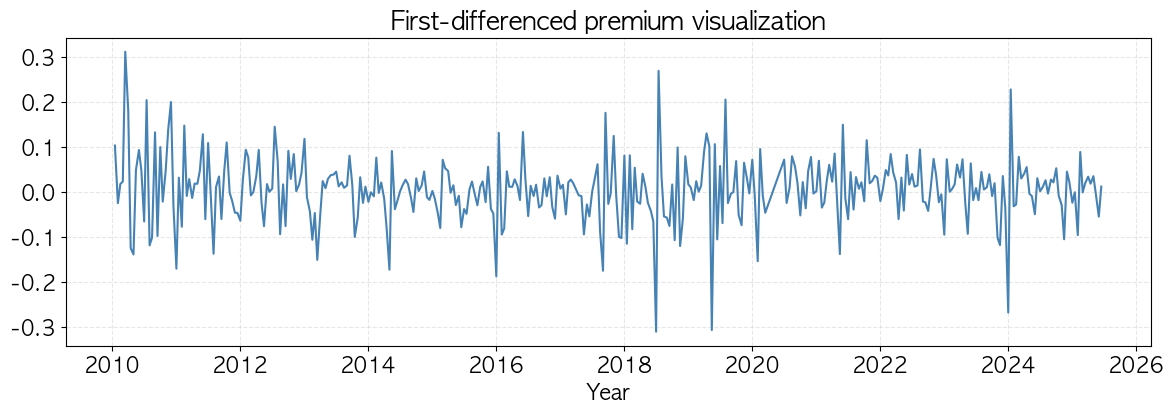

In [8]:
plt.figure(figsize = (14,4))
plt.plot(c['date'][1:], dy, markersize=4.5, linewidth=1.5, color="steelblue")
plt.title("First-differenced premium visualization")
plt.grid(linestyle = '--', alpha = 0.3)
plt.xlabel("Year")
plt.show()

In [9]:
mean_dy = np.mean(dy)
mean_dy

np.float64(0.004570830549640311)

While this value seems small, the mean of 0.005 over a 24 step forecast becomes a 12% increase from last trained value. Since we intend to forecast along a long horizon, we will both plot with and without deterministic trend (trend = t) to our model and see its performances.

In [10]:
test_df = cat_a[((cat_a['year'] == 2025) & (cat_a['mon'] > 6)) | (cat_a['year'] > 2025)].copy()
train_level = c['premium'].values
test_level = test_df['premium'].values

In [11]:
naive_scale = np.mean(np.abs(np.diff(train_level)))    # in-sample naive MAE, straight from the split
h           = 24
LB_LAGS = 10   # lags checked for leftover autocorrelation (Hyndman default for non seasonal data).
                                                                                                # -> min(10, n/5)

def mase(pred):
    return float(np.mean(np.abs(test_level - pred)) / naive_scale)

arima_specs = {
    "drift(0,1,0)": dict(order=(0, 1, 0)),
    "ARIMA(1,1,0)":   dict(order=(1, 1, 0)),
    "ARIMA(1,1,1)":   dict(order=(1, 1, 1)),
    "ARIMA(0,1,1)":   dict(order=(0, 1, 1)),
    "ARIMA(1,1,2)":   dict(order=(1, 1, 2)),   # not the same reduced form as damped Holt due to added trend term
    "ARIMA(2,1,1)":   dict(order=(2, 1, 1)),
    "ARIMA(2,1,2)":   dict(order=(2, 1, 2)),
    "drift(0,1,0)+c": dict(order=(0, 1, 0), trend='t'),
    "ARIMA(1,1,0)+c":   dict(order=(1, 1, 0), trend='t'),
    "ARIMA(1,1,1)+c":   dict(order=(1, 1, 1), trend='t'),
    "ARIMA(0,1,1)+c":   dict(order=(0, 1, 1), trend='t'),
    "ARIMA(1,1,2)+c":   dict(order=(1, 1, 2), trend='t'),   # not the same reduced form as damped Holt due to added trend term
    "ARIMA(2,1,1)+c":   dict(order=(2, 1, 1), trend='t'),
    "ARIMA(2,1,2)+c":   dict(order=(2, 1, 2), trend='t'),
}

rows2 = []
fits = {}
for scale, train_series, back in [("log", np.log(train_level), np.exp),
                                  ("level", train_level, lambda x: x)]:
    for name, spec in arima_specs.items():
        fit = ARIMA(train_series, **spec).fit(method_kwargs={'method': 'nm', 'maxiter': 2000})
        fits[(scale, name)] = fit
        p, d, q = spec['order']
        resid = np.asarray(fit.resid)[fit.loglikelihood_burn:]
        lb_p = acorr_ljungbox(resid, lags=[LB_LAGS], model_df=p + q, return_df=True)['lb_pvalue'].iloc[0]
        rows2.append((scale, name, mase(back(np.asarray(fit.forecast(h)))), fit.aicc, lb_p,
                      "White Noise" if lb_p > 0.05 else "Autocorrelated"))

    for damped in (False, True):
        fit = ETSModel(pd.Series(train_series), error='add', trend='add', damped_trend=damped).fit(disp=False)
        fits[(scale, "ETS damped" if damped else "ETS Holt")] = fit
        lb = acorr_ljungbox(fit.resid, lags=[LB_LAGS], model_df=3 if damped else 2, return_df=True)['lb_pvalue'].iloc[0]
        rows2.append((scale, "ETS damped" if damped else "ETS Holt",
                      mase(back(np.asarray(fit.forecast(h)))), fit.aicc, lb, "White Noise" if lb > 0.05 else "Autocorrelated"))

race_table = (pd.DataFrame(rows2, columns=['scale', 'model', 'holdout_MASE', 'AICc', 'LB_P-value', 'Residuals'])
              .sort_values('holdout_MASE').reset_index(drop=True))
print(race_table.to_string(index=False))

scale          model  holdout_MASE        AICc  LB_P-value      Residuals
  log ARIMA(2,1,2)+c      3.078591 -882.479921    0.155564    White Noise
  log ARIMA(1,1,2)+c      3.087137 -876.262491    0.236019    White Noise
  log ARIMA(2,1,1)+c      3.087188 -876.262419    0.236016    White Noise
  log ARIMA(1,1,1)+c      3.094830 -878.312599    0.324348    White Noise
  log       ETS Holt      3.185409 -875.597758    0.080766    White Noise
  log ARIMA(0,1,1)+c      3.261787 -877.218697    0.238403    White Noise
  log drift(0,1,0)+c      3.275365 -870.252251    0.018682 Autocorrelated
  log ARIMA(1,1,0)+c      3.308341 -875.682292    0.153715    White Noise
level       ETS Holt      3.862775 7078.824453    0.063618    White Noise
level ARIMA(1,1,1)+c      4.224813 7051.879936    0.281957    White Noise
level ARIMA(1,1,2)+c      4.225965 7053.935715    0.202614    White Noise
level ARIMA(2,1,2)+c      4.225988 7056.003206    0.135160    White Noise
  log   ARIMA(2,1,2)      4.234422 -88

The initial results show some interesting information.

1. Adding drift improves forecast performance. The top 10 models for holdout_MASE are all models adjusted with trend and AICc values are similar or lower to its non-trend adjusted counterparts. This shows that the mean of ~ 0.005 really adds up when forecasting over longer horizon.
2. Logs again perform better than levels. For this exercise, even log ETS models perform better. So logs do help stabilise residual variance. For subsequent research tasks, we will be looking at logs mainly.
3. The numbers received for forecasting performance is disappointing. Compared to ~0.5 from Chapter 1, the numbers 3 and above are striking. However, we are predicting 24 steps ahead instead of 7 and the premium growth rate increased from 2025 to 2026. This just shows how difficult it is to predict COE trend with a univariate model. COE pricing is driven by policy and speculation which is difficult to measure compared to natural growth in population.
4. The 5 best performing models are: ARIMA(2,1,2)+c, ARIMA(2,1,2)+c, ARIMA(2,1,2)+c, ARIMA(2,1,2)+c, ETS Holt. While there are models that score slightly better in AICc albeit poorer MASE, this project relies on the ability to forecast far ahead, so we put heavier weight on better MASE performance when two tests results conflict.
5. ARIMA(1,1,2)+c and ARIMA(2,1,1)+c have the same MASE and AICc values up until its fourth digits. For a seemingly different model, the performance is almost equivalent. The numbers look wrong and will be tested below.
6. ARIMA(2,1,2)+c is the definite winner here with the best MASE performance and has one of the lowest AICc. This goes against our ACF and PACF values, however does not mean this model is wrong as the plots could be misleading.
7. Unlike Chapter 1, log and level drift underperforms against more complex models in MASE with log failing Ljung-Box test. This shows that the premium movement is highly volatile and less predictable with simple models. Similarly, ETS damped also fails Ljung-Box test for both logs and levels showing that introducing damping misses out key structure in the overall trend.

We test Note 4 by finding the coefficients for each extra AR, MA terms. If they add no value to the model, i.e. 0 coefficient, we can conclude that they are basically the same model with noise.

In [12]:
print("ARIMA(1,1,2) & ARIMA(2,1,1) coefficient diagnostics")
print(fits[("log", 'ARIMA(1,1,2)+c')].maroots,
      fits[("log", 'ARIMA(2,1,1)+c')].arroots)

ARIMA(1,1,2) & ARIMA(2,1,1) coefficient diagnostics
[  1.65436104 -79.94245227] [ 2.3354709  78.37221809]


The second roots for the MA term in ARIMA(1,1,2) and the AR term in ARIMA(2,1,1) are very large at −79.9 and 78.4, respectively. Their corresponding inverse roots (reciprocals) are −0.0125 and 0.0128.

From our reference book, a model is stationary and invertible when all inverse roots lie strictly inside the unit circle. These values are inside but it is almost at the origin; these inverse roots are virtually zero (≈0), the second-order terms contribute almost no weight to the model equation.

Stripping the extra terms collapses both models down to the same underlying ARMA(1,1) process on the differenced data. Therefore, the two models are functionally equivalent, with the minor differences in estimation amounting to noise from fitting a redundant extra parameter. Consequently, we test ARIMA(2,1,2)+c as well for similar patterns.

In [13]:
print("ARIMA(2,1,2) coefficient diagnostics")
print(fits[("log", 'ARIMA(2,1,2)+c')].arroots,
      fits[("log", 'ARIMA(2,1,2)+c')].maroots)
print("-------------------")
print("ARIMA(1,1,1) coefficient diagnostics")
print(fits[("log", 'ARIMA(1,1,1)+c')].arroots,
     fits[("log", 'ARIMA(1,1,1)+c')].maroots)

ARIMA(2,1,2) coefficient diagnostics
[1.0245175  1.43624025] [1.07672941-0.09298729j 1.07672941+0.09298729j]
-------------------
ARIMA(1,1,1) coefficient diagnostics
[2.2187302] [1.62465813]


This one has different issue, with the first AR root being close to 1. As seen before, one of the AR root is 1.025 close to unit root of 1, showing signs of over parameterisation. Removing this term collapses to ARIMA(1,1,2) which we have already diagnosed to be an overparameterised version of ARIMA(1,1,1). We observe that the coefficients of ARIMA(1,1,1)'s terms are healthier at 2.21 and 1.62 respectively, Therefore, we conclude that our top 4 models are essentially ARIMA(1,1,1) with noise.

Hence, we scrap Notes 3,4 and 5 while maintaing emphasis on MASE over AICc. We will be taking the top models as follows:

In [14]:
print(race_table[3:8].drop(6).to_string(index=False)) #Performance of top performers

scale          model  holdout_MASE        AICc  LB_P-value   Residuals
  log ARIMA(1,1,1)+c      3.094830 -878.312599    0.324348 White Noise
  log       ETS Holt      3.185409 -875.597758    0.080766 White Noise
  log ARIMA(0,1,1)+c      3.261787 -877.218697    0.238403 White Noise
  log ARIMA(1,1,0)+c      3.308341 -875.682292    0.153715 White Noise


> Disclaimer: I have not managed to find solution to how the two maroots for ARIMA(2,1,2) are exactly the same, but overparematerisation should be causing an error.

Now we proceed with exogenous time series regression with two predictors, resident growth and COE quota. With the same test criterion, we will judge whether having exogenous variables help explain the premium trend better.

## 5. Dynamic regression with Resident Population and COE Quota

Now we move onto the main event! We plot a dynamic regression ax explained in our reference book - FPP chapter 10, the premium regressed on the two predictors with ARIMA errors. Because all three series are non stationary, we do the regression on the differenced, stationary series, which is the FPP prescription. Concretely we model the change in log premium against the change in log resident population and the change in quota, with ARMA(1,1) errors and a constant. The regressors are standardised so the coefficients are comparable.

Before fitting, we will fit a heatmap on the levels of the data and its differences to find its correlation.

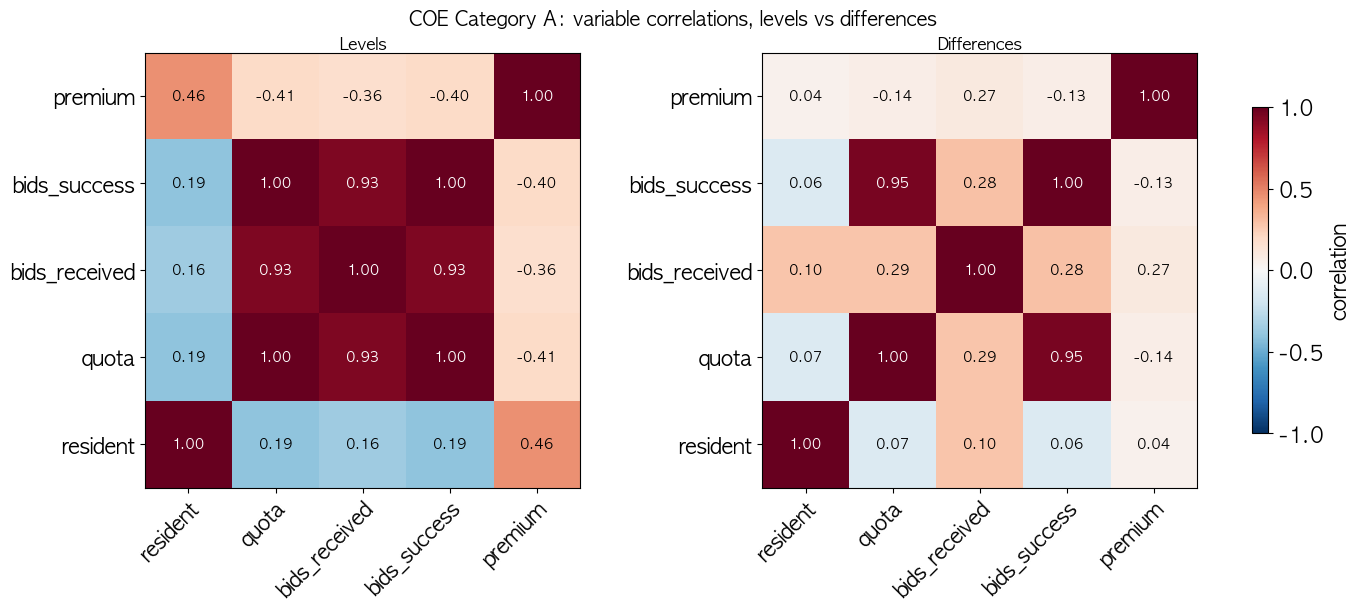

In [15]:
cols = ['premium', 'bids_success', 'bids_received', 'quota', 'resident']
labs = ['resident', 'quota', 'bids_received', 'bids_success', 'premium']
panels = [(c[cols].corr().iloc[::-1], 'Levels'),
          (c[cols].diff().corr().iloc[::-1], 'Differences')]


fig_map, axes_map = plt.subplots(1, 2, figsize=(14, 6), layout='constrained')

for ax_hm, (m, title) in zip(axes_map, panels):
    v = m.values
    im = ax_hm.imshow(v, cmap='RdBu_r', vmin=-1, vmax=1)

    ax_hm.set_xticks(range(5))
    ax_hm.set_xticklabels(labs, rotation=45, ha='right', rotation_mode='anchor')
    ax_hm.set_yticks(range(5))
    ax_hm.set_yticklabels(cols)
    
    for i in range(5):
        for j in range(5):
            ax_hm.text(i, j, f"{v[i, j]:.2f}", ha='center', va='center',
                    color='white' if abs(v[i, j]) > 0.55 else 'black', fontsize=10)
    ax_hm.set_title(title, fontsize=12, pad = -50)

fig_map.colorbar(im, ax=axes_map, shrink=0.75, label='correlation')
fig_map.suptitle('COE Category A: variable correlations, levels vs differences', fontsize=14)
plt.show()

### The heatmap rejects the population correlation and supports the quota correlation weakly.

The heatmap shows spurious results. Resident population correlates at 0.46 with the premium in levels, which looked like a relationship, but the two series only share an upward drift over 2010 to 2025. When we difference that shared trend away to match our d = 1 setting, the correlation collapses to 0.04, which is almost zero. Furthermore, the strong inverse relationship between quota and premium in levels, at about -0.41 and observed from the trendlines in Section 2, weakens to -0.14 once differenced. So the population relationship does not survive differencing at all, and the quota relationship survives only weakly, and shows that an increase in quota does not translate to proportional decrease in price. Here, we rule out population as a predictor and reject our hypothesis that resident population affects price changes while still keeping quota as a candidate.

Furthermore, the heatmap also surfaces one variable this project did not plan for. Bids received keeps a differenced correlation of 0.27 with the premium, the strongest of the four candidates. Because COE allocations are fixed by quota, a higher volume of bids increases competitive pressure, raising the clearing price required to secure a certificate. However, forecasting future bids_received is also difficult to predict as many possible cause such as speculation in price and demand for the coe affects it, which we don't have exact data for. So, we keep this as an interesting result rather than considering it an alternative candidate to population. 

Finally, a weak relationship (corr: 0.10) can be seen between changes in resident population and changes in bids received, showing that population growth alone does not necessarily translate to increased bidding. This also shows how resident fails as a predictor: We need it to explain bids received well so that we can justify the use of resident to explain the demand side of this market.

### Overlooked research tasks

The heatmap forced a review of the research design, and two design errors surfaced.

First, I had assumed COE bids come directly from car buyers. A basic check shows this is rarely the case: dealers typically bid on behalf of buyers, so any demand pressure from population growth reaches the bidding table only indirectly, diluted through intermediaries ([COE mechanics](https://www.sciencedirect.com/science/article/abs/pii/S0305048397000790)). I also underestimated the bidding mechanism itself. Bids are submitted freely and the premium settles at the lowest successful bid, so strategic bidding behaviour matters at least as much as the simple demand and supply story this project was built on.

Second, there was a frequency mismatch than we overlooked. Resident population is an annual, slow moving stock, while the premium is a biweekly auction outcome. So when we slice the year difference by 24 to compare it to biweekly fluctuations of coe, it is designed to fail in correlation. Hence, resident population as a predictor, not to mention feeding the forecasted trend value to a dynamic regression is unlikely to generate any meaningful insight. And hence, resulting in a near zero correlation.

There is also a specification mismatch we only confronted at this stage. We concluded in chapter 1 that resident population behaves like d = 2, while the premium is d = 1. A dynamic regression needs both sides differenced to stationarity on the same footing, and with mismatched orders we would be regressing the change in the premium on the acceleration of the population, which is hard to interpret and even harder to justify. The reference book's dynamic regression setup assumes the response and the predictors can be made stationary the same way, and that premise fails here.

Also, Category A premium rate went through a small change in its classification after May 2022 first biding results, where electric vehicles were added to the previously petrol only car types. So there was an increase in utility of owning Category A premium, and we don't know how this would have affected the overall bidding system. (Probably increased but difficult to test)

### Two main lessons are recorded from this stage, and they carry more value than the results.

1. Skimming a reference then heading into a project is extremely arrogant. Several outputs I could not explain, and several detours in this project, traced back to warnings and fine print I had read past. Quite a number of times, the answer was already in the book, and the cost of not reading carefully the first time was paid in rework and ultimately, having to pause due to a structural error in initial methodology.

2. Domain knowledge matters. One of my professors pointed out that domain knowledge matters at least as much as statistical knowledge underlying a machine learning model and the ability to apply it in codes. I studied time series and forecasting methods through the reference book but under researched the market this project actually models, from how bids are placed to how the quota is set. Knowing what the numbers mean turned out to matter more than any single technique applied to it. Technique sets the pace, but domain knowledge sets the direction, and pace without direction only moves you further down the wrong road.

These are registered alongside the statistical results, and they set an important checklist for future project: read the fine print, and research the market before modelling it.

### Checking for delayed effects

Before fitting the regression, one more question from the level charts needs an answer. Quota and premium visibly move inversely over the years, so even if the contemporaneous differenced correlation is weak, quota changes might lead premium changes with a delay. We check the correlation between the change in log premium and earlier changes in each regressor.

In [16]:
d_res = np.diff(np.log(c['resident'].values))         # change in log resident
d_quo = np.diff(c['quota'].values.astype(float))      # change in quota

print(f"lagged correlation of d(log premium)_t with each regressor's change")
print(" k :  quota   resident")
for k in [0, 1, 2, 3, 4, 5, 6, 7, 8]:
    cq = np.corrcoef(dy[k:], d_quo[:len(d_quo) - k] if k > 0 else d_quo)[0, 1]
    cr = np.corrcoef(dy[k:], d_res[:len(d_res) - k] if k > 0 else d_res)[0, 1]
    print(f"{k:2} : {cq:+.3f}  {cr:+.3f}")

lagged correlation of d(log premium)_t with each regressor's change
 k :  quota   resident
 0 : -0.166  +0.022
 1 : +0.065  +0.001
 2 : +0.017  +0.019
 3 : +0.039  +0.027
 4 : -0.061  +0.031
 5 : +0.002  +0.022
 6 : -0.047  +0.011
 7 : -0.086  +0.002
 8 : +0.016  -0.016


The first quota change is more relevant compared all other lags. At lag 0 the correlation is -0.17 and every lag from 1 to 8 decreases its correlation value. So there is no delayed effect to exploit: whatever quota tells us about the premium, it tells us in the same differencing. Resident population shows no actionable change on lags.

With the checks done, we fit the dynamic regression on the differenced series, following our top performer ARIMA(1,1,1)'s p,q values to fit ARMA(1,1) errors and a constant, and remove the regressors one at a time. We are feeding the holdout quota values from our test set. Since the government publishes expected quota values. If this model performs well, that indicates that given quota values, we can predict future premium better than a univariate model.

In [17]:
test_df['t'] = test_df['year'] + (test_df['mon'] - 1) / 12 + (test_df['bidding_no'] - 1) / 24
test_df = test_df.sort_values('t').reset_index(drop=True)
test_df['resident'] = np.interp(test_df['t'], res['Year'] + 0.5, res['Value'])   #Applying the same divide by 24 to test set.

# Quota now enters in logs, matching the premium and every univariate model. Both sides in logs
# makes the coefficient an elasticity: a percent change in premium per percent change in quota.
d_quo_log      = np.diff(np.log(c['quota'].values.astype(float)))
d_quo_log_test = np.diff(np.log(np.concatenate([[c['quota'].iloc[-1]], test_df['quota'].values.astype(float)])))
d_res_test = np.diff(np.log(np.concatenate([[c['resident'].iloc[-1]], test_df['resident'].values])))

def standardise(x_train, x_test):
    mu, sd = x_train.mean(), x_train.std() 
    return (x_train - mu) / sd, (x_test - mu) / sd #Standardising using training mean and sd. Explanation below.

Zq_train, Zq_test = standardise(d_quo_log, d_quo_log_test) #Since population and quota are on different scales, the coefficients
                                                    #of the model will look wildly different. Hence, we standardise to make it comparable.
Zr_train, Zr_test = standardise(d_res, d_res_test)
last_train_logp = y[-1]

fits_dy = {}
def dynreg(X_train, X_test, reg_name):
    f = ARIMA(dy, exog=X_train, order=(1, 0, 1)).fit(method_kwargs={'method': 'nm', 'maxiter': 1000})
    fits_dy[reg_name] = f
    d_fore = np.asarray(f.forecast(h, exog=X_test))
    pred_level = np.exp(last_train_logp + np.cumsum(d_fore))    # rebuild the premium level from log forecasts
    betas = {n: float(np.asarray(f.params)[f.param_names.index(n)]) for n in f.param_names if n.startswith('x')} #takeout data whose columns name starts 
                                                                                                                  #with x to take out values corresponding to the actual regressors.
    pvals = {n: float(np.asarray(f.pvalues)[f.param_names.index(n)]) for n in f.param_names if n.startswith('x')}
    resid = np.asarray(f.resid)[f.loglikelihood_burn:]
    lb_p = acorr_ljungbox(resid, lags=[LB_LAGS], model_df=2, return_df=True)['lb_pvalue'].iloc[0] #P+q = 2 since we are using ARMA(1,1)
    return f.aicc, mase(pred_level), betas, pvals, lb_p, "White Noise" if lb_p > 0.05 else "Autocorrelated"

dyn_rows = []
for reg_name, Xtr, Xte in [('none (univariate)', None, None), #Just recalculating ARIMA(1,1,1)
                           ('+ resident', Zr_train.reshape(-1, 1), Zr_test.reshape(-1, 1)),
                           ('+ quota', Zq_train.reshape(-1, 1), Zq_test.reshape(-1, 1)),
                           ('+ both', np.column_stack([Zr_train, Zq_train]), np.column_stack([Zr_test, Zq_test]))]:
    aicc_v, mase_v, betas, pvals, lb_result, lb_res = dynreg(Xtr, Xte, reg_name)
    coef_txt = ", ".join(f"{k}={betas[k]:+.4f} (p={pvals[k]:.3f})" for k in betas) or "-"
    dyn_rows.append((reg_name, round(aicc_v, 2), round(mase_v, 3), coef_txt, lb_result, lb_res))
pd.DataFrame(dyn_rows, columns=['exog', 'AICc', 'holdout_MASE', 'coefficients (x1=resident, x2=quota)', 'lb_p', 'Residuals'])

,exog,AICc,holdout_MASE,"coefficients (x1=resident, x2=quota)",lb_p,Residuals
0,none (univariate),-878.31,3.095,-,0.324362,White Noise
1,+ resident,-876.42,3.572,x1=+0.0011 (p=0.754),0.324281,White Noise
2,+ quota,-890.50,3.192,x1=-0.0142 (p=0.000),0.331576,White Noise
3,+ both,-888.78,3.809,"x1=+0.0014 (p=0.640), x2=-0.0143 (p=0.000)",0.332785,White Noise


We use training mean and sd to standardise the test set to prevent future information leakage and ensuring comparable scale for training and test. Ljung-Box results all claim residuals are white noise with similar p-values. We checked for ARIMA(0,1,1) and ARIMA(1,1,0) as regression errors which both underperforms both in AICc and holdout_MASE.

## 6. Verdict on effectiveness of extra predictor

A definitive no for population as expected, and less definitive no for quota.

**Resident population: Does not help.** Its coefficient is essentially zero and nowhere near significant, with a p-value of 0.75, meaning the data cannot distinguish the coefficient from zero. Adding it raises AICc from -878.3 to -876.4 because it spends a parameter for nothing, and it worsens the holdout MASE from 3.10 to 3.57. This is the differenced correlation of 0.04 from the heatmap making its appearance. The apparent relationship in levels was the shared trend, and once that is removed there is nothing left. The population simply is not what moves the premium. Adding population to quota only model worsens its performance.

**Quota: There is a real relationship but forecast performance is worse.** Its coefficient is significant with a near zero p-value and the sign is sensible at -0.0142, more quota comes with a smaller price rise. Adding it improves AICc clearly, from -878.3 to -890.5, the best in sample fit of the four. And yet it performs slightly worse on the holdout forecast, from 3.10 to 3.19. Quota genuinely moves with the premium inside the sample, but that relationship does not translate into significant forecasting power over a year. This is genuinely sad.

For forecasting further ahead, we have quota values up until October. However, the quota values are compounded for 3 months, so again, we need to divide by 6 to fit the biweekly quota release schedule. Hence, we expect variance and uncertainty to only increase. Anything further than that, we would have to model quota trend, which again just adds to more issues. 

So, we will plot up until October just to make a comparison. And we will make a judgement here that dynamic regression with quota performs worse on holdout sample, and trying to extrapolate further than October using expected quota values will only worsen its performance (we would need MASE performance to be significantly better to warrant this research path). So univariate model remains the better forecast method.

### Below, we plot our top univariate model and quota dynamic regression model against actual premium from test set.

Backtest Jul 2025 to Jun 2026, actual final premium S$123,847
                holdout_MASE    forecast       lo95        hi95 points_in_95PI
ARIMA(1,1,1)+c         3.095  109931.571  66640.918  181344.296          24/24
ARIMA(0,1,1)+c         3.262  109450.365  61348.731  195266.995          24/24
ARIMA(1,1,0)+c         3.308  109317.490  59331.538  201415.875          24/24
ETS Holt               3.185  109865.080  55124.816  218963.739          24/24
quota model            3.192  109938.102  70488.260  172875.740          24/24


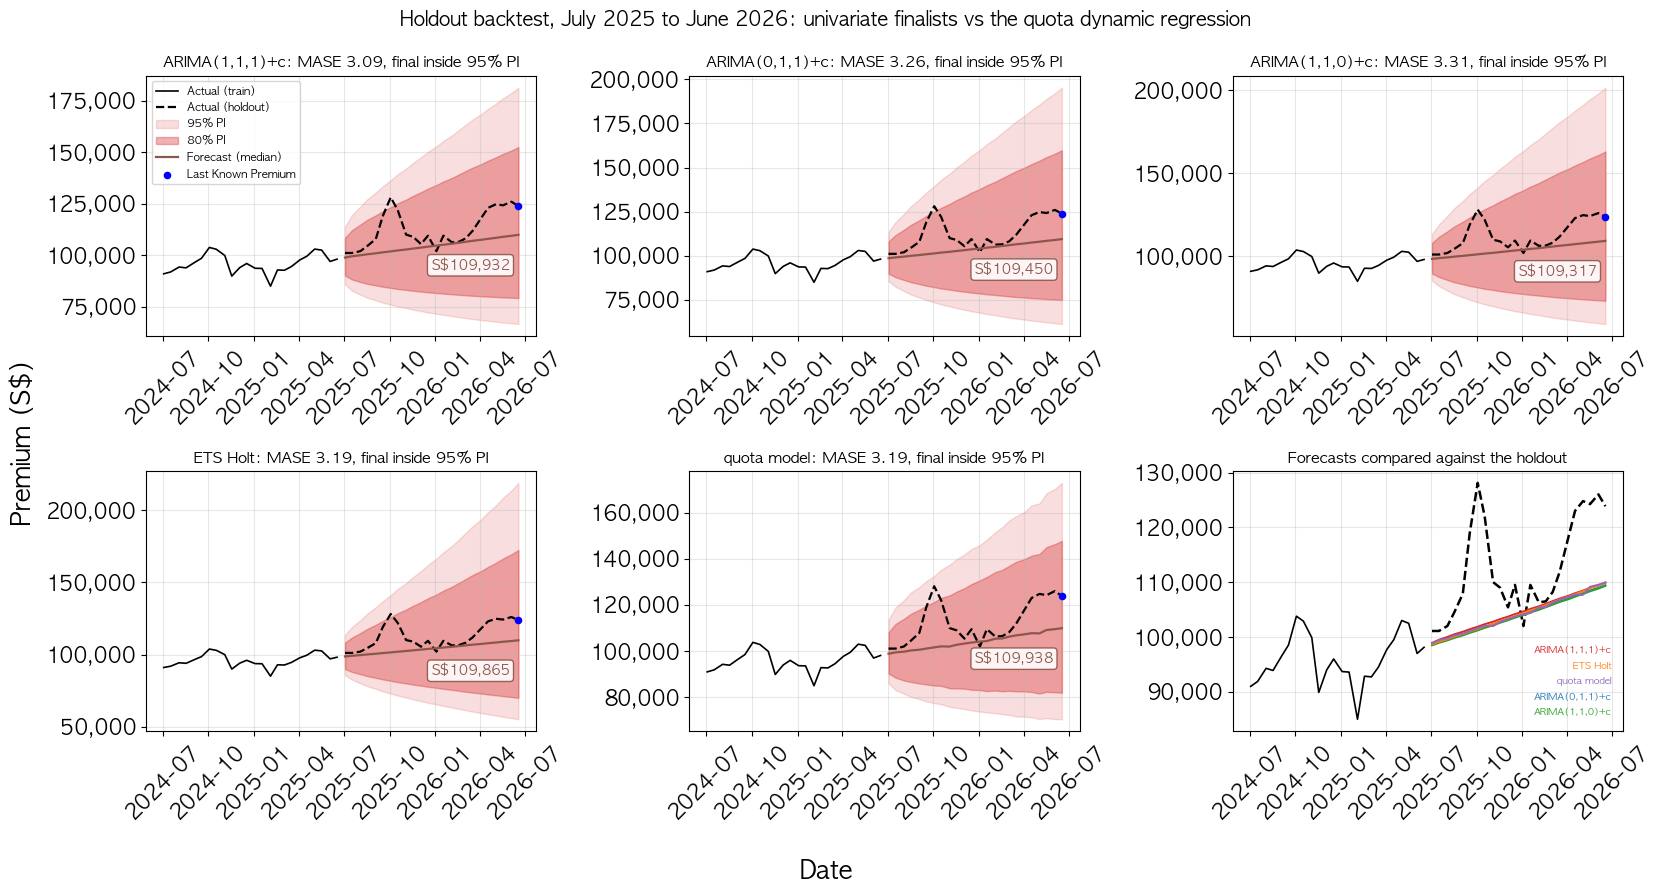

In [31]:
H_BT = 24                                                
bt_dates_hist = c['date']
bt_dates_test = pd.to_datetime(dict(year=test_df['year'], month=test_df['mon'],
                                    day=np.where(test_df['bidding_no'] == 1, 3, 17)))
bt_actual = test_level                                     # true premiums over the holdout

# the Section 5 quota model, reused rather than refitted (log quota, differenced)
bt_dynreg_fit = fits_dy['+ quota']
N_SIM_BT = 20000                                           # paths for the dynamic regression bands

bt_specs = ['ARIMA(1,1,1)+c', 'ARIMA(0,1,1)+c', 'ARIMA(1,1,0)+c', 'ETS Holt', 'quota model']

def backtest_fc(name):
    """Forecast H_BT ahead. Reuses the Section 4 fits and the Section 5 quota fit; nothing is refitted."""
    if name == 'quota model':
        d_fore = np.asarray(bt_dynreg_fit.forecast(H_BT, exog=Zq_test))   # actual published holdout quota
        log_med = last_train_logp + np.cumsum(d_fore)
        sims = np.asarray(bt_dynreg_fit.simulate(H_BT, anchor='end', repetitions=N_SIM_BT, #We are using simulate function instead as the
                                                 exog=Zq_test, random_state=0)).reshape(H_BT, -1) #the prediction intervals widens 31X.
        log_paths = last_train_logp + np.cumsum(sims, axis=0)
        out_b = (log_med,
                 np.percentile(log_paths, 10, axis=1), np.percentile(log_paths, 90, axis=1),
                 np.percentile(log_paths, 2.5, axis=1), np.percentile(log_paths, 97.5, axis=1))
    elif name == 'ETS Holt':
        pr_b = fits[('log', name)].get_prediction(start=len(y), end=len(y) + H_BT - 1)
        b95, b80 = pr_b.summary_frame(alpha=0.05), pr_b.summary_frame(alpha=0.20)
        out_b = (b95['mean'].values, b80['pi_lower'].values, b80['pi_upper'].values,
                 b95['pi_lower'].values, b95['pi_upper'].values)
    else:
        pr_b = fits[('log', name)].get_forecast(H_BT)
        c95, c80 = np.asarray(pr_b.conf_int(alpha=0.05)), np.asarray(pr_b.conf_int(alpha=0.20))
        out_b = (np.asarray(pr_b.predicted_mean), c80[:, 0], c80[:, 1], c95[:, 0], c95[:, 1])
    return [np.exp(np.asarray(v)) for v in out_b]           # back to premium scale

fc_bt = {name: backtest_fc(name) for name in bt_specs}

bt_summary = pd.DataFrame(
    {name: [mase(fc[0]), fc[0][-1], fc[3][-1], fc[4][-1],
            int(np.sum((fc[3] <= bt_actual) & (bt_actual <= fc[4])))]
     for name, fc in fc_bt.items()},
    index=['holdout_MASE', 'forecast', 'lo95', 'hi95', 'points_in_95PI']).T
bt_summary['points_in_95PI'] = bt_summary['points_in_95PI'].astype(int).astype(str) + f"/{H_BT}"
print(f"Backtest {bt_dates_test.iloc[0]:%b %Y} to {bt_dates_test.iloc[-1]:%b %Y}, "
      f"actual final premium S${bt_actual[-1]:,.0f}")
print(bt_summary.round(3).to_string())

bt_hist = bt_dates_hist >= pd.Timestamp('2024-07-01')
fig_bt, axes_bt = plt.subplots(2, 3, figsize=(17, 9))
axes_bt = axes_bt.ravel()
bt_palette = ['tab:red', 'tab:blue', 'tab:green', 'tab:orange', 'tab:purple']

for ax_bt, name in zip(axes_bt, bt_specs):
    med_b, lo80_b, hi80_b, lo95_b, hi95_b = fc_bt[name]
    ax_bt.plot(bt_dates_hist[bt_hist], train_level[bt_hist.values], color='black', lw=1.2, label='Actual (train)')
    ax_bt.plot(bt_dates_test, bt_actual, color='black', lw=1.6, ls='--', label='Actual (holdout)')
    ax_bt.fill_between(bt_dates_test, lo95_b, hi95_b, color='tab:red', alpha=0.15, label='95% PI')
    ax_bt.fill_between(bt_dates_test, lo80_b, hi80_b, color='tab:red', alpha=0.35, label='80% PI')
    ax_bt.plot(bt_dates_test, med_b, color='tab:brown', lw=1.6, label='Forecast (median)')
    inside_b = lo95_b[-1] <= bt_actual[-1] <= hi95_b[-1]
    ax_bt.scatter([bt_dates_test.iloc[-1]], [bt_actual[-1]], s=20, zorder=20,
                  color=('blue' if inside_b else 'crimson'), label='Last Known Premium')
    ax_bt.set_title(f"{name}: MASE {mase(med_b):.2f}, final {'inside' if inside_b else 'OUTSIDE'} 95% PI",
                    fontsize=11)
    ax_bt.grid(True, alpha=0.3)
    ax_bt.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
    ax_bt.tick_params(axis='x', rotation=45)
    ax_bt.annotate(f"S${med_b[-1]:,.0f}", xy=(bt_dates_test.iloc[-1], med_b[-1]),
                   xytext=(-6, -25), textcoords='offset points', ha='right',
                   fontsize=10, fontweight='bold', color='tab:brown',
                   bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='tab:brown', alpha=0.9))
axes_bt[0].legend(loc='upper left', fontsize=8)

ax_bt_cmp = axes_bt[5]
ax_bt_cmp.plot(bt_dates_hist[bt_hist], train_level[bt_hist.values], color='black', lw=1.2, label='Actual')
ax_bt_cmp.plot(bt_dates_test, bt_actual, color='black', lw=1.8, ls='--', label='Actual (holdout)')
for name, colr in zip(bt_specs, bt_palette):
    ax_bt_cmp.plot(bt_dates_test, fc_bt[name][0], color=colr, lw=1.4, label=name)
for rank, name in enumerate(sorted(bt_specs, key=lambda n: mase(fc_bt[n][0]))):
    ax_bt_cmp.annotate(f"{name}",
                       xy=(0.97, 0.30 - rank * 0.06), xycoords='axes fraction', ha='right',
                       fontsize=7, color=bt_palette[bt_specs.index(name)])
ax_bt_cmp.set_title('Forecasts compared against the holdout', fontsize=11)
ax_bt_cmp.grid(True, alpha=0.3)
ax_bt_cmp.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
ax_bt_cmp.tick_params(axis='x', rotation=45)

fig_bt.suptitle('Holdout backtest, July 2025 to June 2026: univariate finalists vs the quota dynamic regression',
                fontsize=14)
fig_bt.supxlabel('Date'); fig_bt.supylabel('Premium (S$)')
plt.tight_layout()
plt.show()

## 7. Model selection, forecasting and verdict

The univariate shortlist from Section 4 was log ARIMA(1,1,1)+c, log ETS Holt, log ARIMA(0,1,1)+c and log ARIMA(1,1,0)+c, after the root diagnostics collapsed the larger models into ARIMA(1,1,1). We refit these four on the full 2010 to June 2026 sample and, for comparison, the quota dynamic regression as well with biweekly split of ([official quota results](https://www.lta.gov.sg/content/dam/ltagov/news/press/2026/260724_COEQuota_Aug-Oct26_AnnexA.pdf)), and project until October bid 2. This will be a personal benchmark to see if our quota model can win against univariate for an actual forecasting task.

Last observed: 17 Jun 2026, premium S$123,847, quota 1,251
July 1,198.5 per exercise, Aug to Oct 1,189.0 per exercise, horizon 8 exercises
  quota elasticity (x1) = -0.0137, p = 0.0000

Projection endpoint, 17 October 2026 (points are medians):
                  median      lo80      hi80     lo95      hi95
ARIMA(1,1,1)+c  128842.0  105638.0  157144.0  95097.0  174561.0
ARIMA(0,1,1)+c  129194.0  103614.0  161090.0  92191.0  181049.0
ARIMA(1,1,0)+c  129106.0  102561.0  162520.0  90796.0  183579.0
ETS Holt        130887.0  104061.0  164628.0  92164.0  185879.0
quota model     129805.0  108027.0  155955.0  97948.0  171930.0


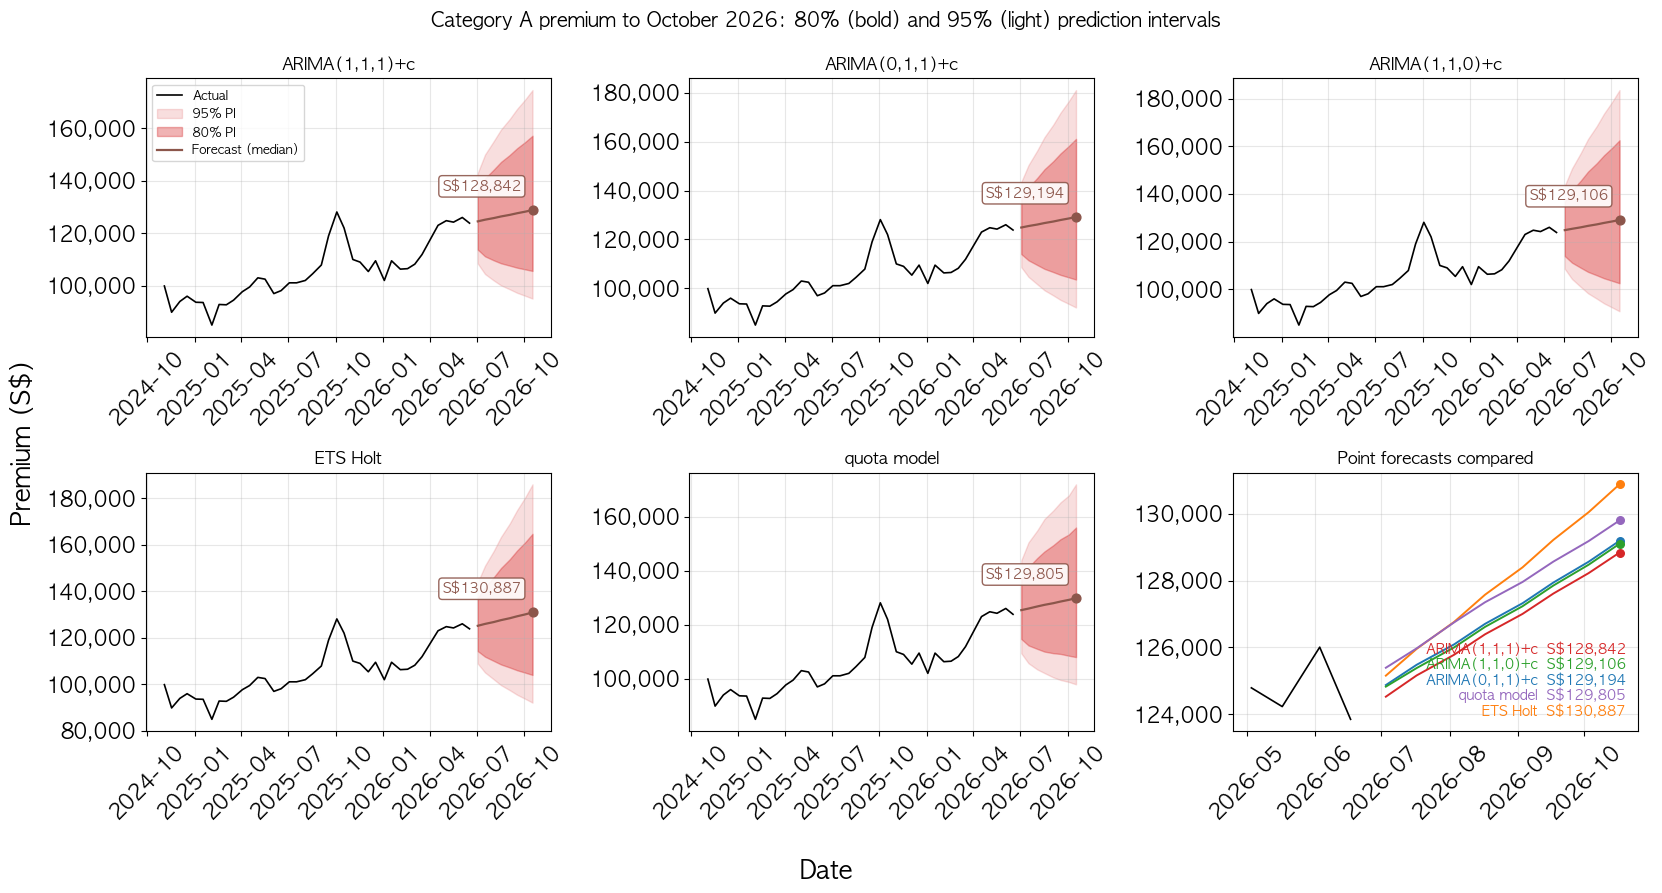

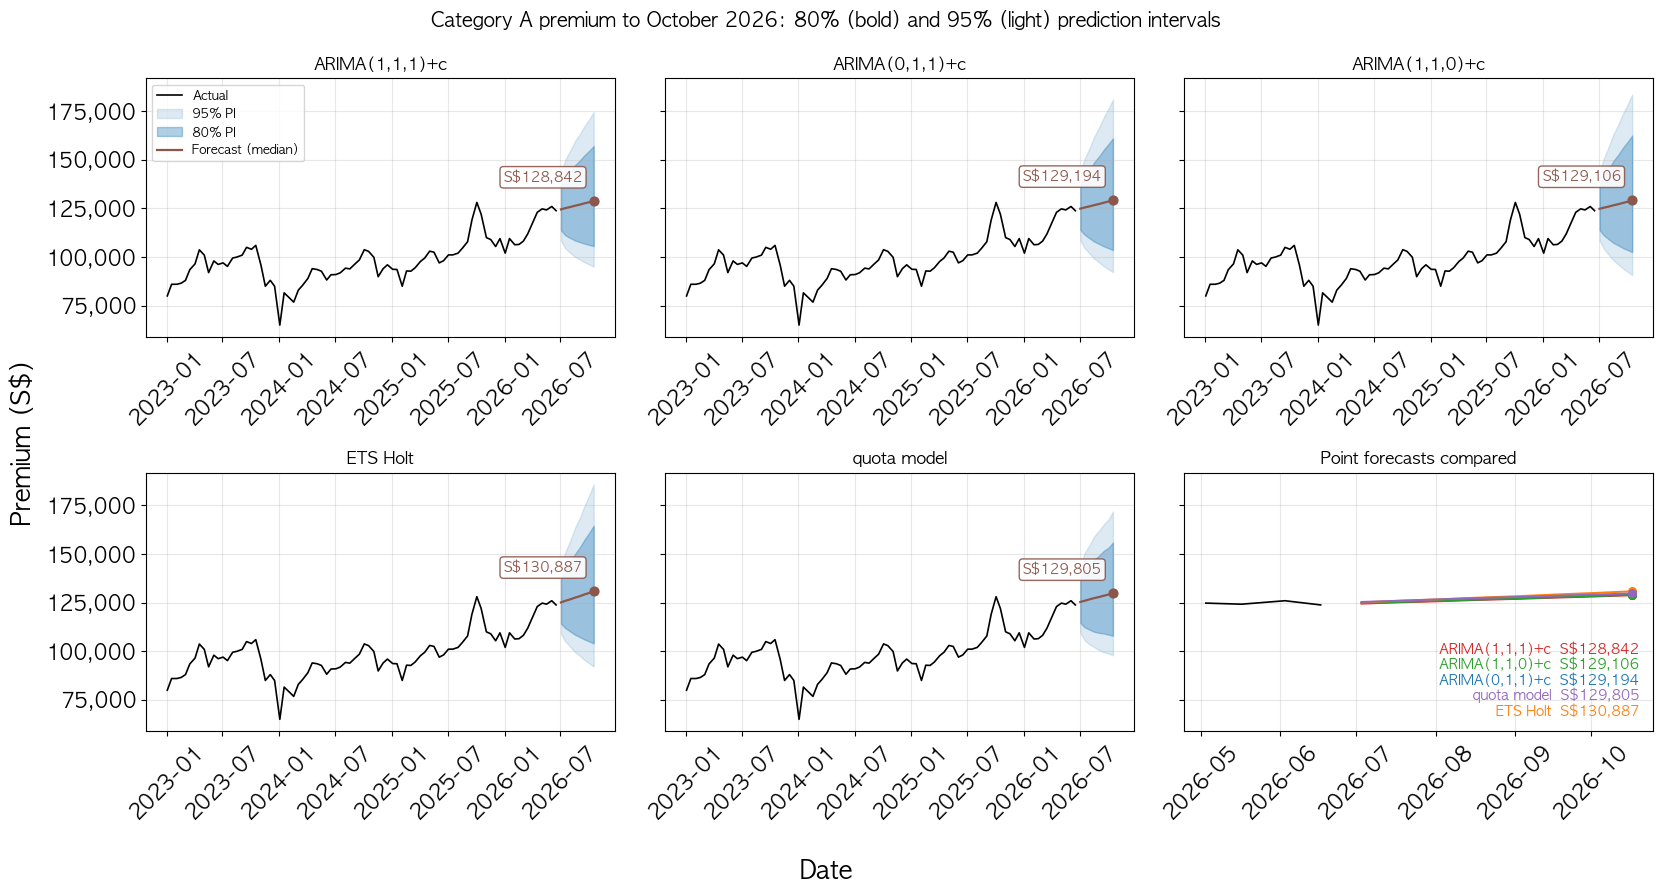

In [36]:
cat_full = df[df['vehicle_class'] == 'Category A'].copy()
cat_full['year'] = cat_full['month'].str[:4].astype(int)
cat_full['mon']  = cat_full['month'].str[5:7].astype(int)
cat_full = cat_full.sort_values(['year', 'mon', 'bidding_no']).reset_index(drop=True)
cat_full['date'] = pd.to_datetime(dict(year=cat_full['year'], month=cat_full['mon'],
                                       day=np.where(cat_full['bidding_no'] == 1, 3, 17)))

full_dates = cat_full['date']
full_prem  = cat_full['premium'].values.astype(float)
full_quota = cat_full['quota'].values.astype(float)
full_logp  = np.log(full_prem)

# Announced Category A quota totals (LTA quarterly announcements)
TOTAL_MAY_JUL_2026 = 7434      # May to July 2026
TOTAL_AUG_OCT_2026 = 7134      # Aug to Oct 2026

# July is the residual of the May-July announcement after the May and June exercises we observe
may_2026 = cat_full.loc[(cat_full['year'] == 2026) & (cat_full['mon'] == 5), 'quota'].sum()
jun_2026 = cat_full.loc[(cat_full['year'] == 2026) & (cat_full['mon'] == 6), 'quota'].sum()
jul_each     = (TOTAL_MAY_JUL_2026 - may_2026 - jun_2026) / 2   # 2 exercises in July
aug_oct_each = TOTAL_AUG_OCT_2026 / 6                           # 6 exercises across Aug, Sep, Oct

future_quota = np.array([jul_each] * 2 + [aug_oct_each] * 6)
future_dates = pd.Series([pd.Timestamp(2026, m, d) for m in (7, 8, 9, 10) for d in (3, 17)])
H_FC = len(future_quota)                                        # 8 exercises, July to October 2026
print(f"Last observed: {full_dates.iloc[-1]:%d %b %Y}, premium S${full_prem[-1]:,.0f}, quota {full_quota[-1]:,.0f}")
print(f"July {jul_each:,.1f} per exercise, Aug to Oct {aug_oct_each:,.1f} per exercise, horizon {H_FC} exercises")

final_specs = [('ARIMA(1,1,1)+c', dict(order=(1, 1, 1), trend='t')),
               ('ARIMA(0,1,1)+c', dict(order=(0, 1, 1), trend='t')),
               ('ARIMA(1,1,0)+c', dict(order=(1, 1, 0), trend='t')),
               ('ETS Holt',       'ETS'),
               ('quota model',    'DYNREG')]

# Quota in logs, matching Section 5. Fitted fresh on every known exercise to June 2026, and the
# future quota is standardised with the SAME statistics as the fitted data, never its own.
d_quo_log_full   = np.diff(np.log(full_quota))
d_quo_log_future = np.diff(np.log(np.concatenate([[full_quota[-1]], future_quota])))
fc_qmu, fc_qsd = d_quo_log_full.mean(), d_quo_log_full.std()
Zq_full   = ((d_quo_log_full   - fc_qmu) / fc_qsd).reshape(-1, 1)
Zq_future = ((d_quo_log_future - fc_qmu) / fc_qsd).reshape(-1, 1)
full_dlogp = np.diff(full_logp)                      # differenced log premium, the response
last_full_logp = full_logp[-1]
N_SIM_FC = 20000                                     # paths for the dynamic regression bands

def forecast_ahead(spec):
    if spec == 'ETS':
        fit_ = ETSModel(pd.Series(full_logp), error='add', trend='add').fit(disp=False)
        pr_ = fit_.get_prediction(start=len(full_logp), end=len(full_logp) + H_FC - 1)
        f95, f80 = pr_.summary_frame(alpha=0.05), pr_.summary_frame(alpha=0.20)
        out = (f95['mean'].values, f80['pi_lower'].values, f80['pi_upper'].values,
               f95['pi_lower'].values, f95['pi_upper'].values)
    elif spec == 'DYNREG':
        # same specification as Section 5, refitted on every known exercise to June 2026
        fit_ = ARIMA(full_dlogp, exog=Zq_full, order=(1, 0, 1)).fit(
            method_kwargs={'method': 'nm', 'maxiter': 1000})
        d_fore = np.asarray(fit_.forecast(H_FC, exog=Zq_future))
        log_med = last_full_logp + np.cumsum(d_fore)
        sims = np.asarray(fit_.simulate(H_FC, anchor='end', repetitions=N_SIM_FC,
                                        exog=Zq_future, random_state=0)).reshape(H_FC, -1)
        log_paths = last_full_logp + np.cumsum(sims, axis=0)
        out = (log_med,
               np.percentile(log_paths, 10, axis=1), np.percentile(log_paths, 90, axis=1),
               np.percentile(log_paths, 2.5, axis=1), np.percentile(log_paths, 97.5, axis=1))
        qi = fit_.param_names.index('x1')
        print(f"  quota elasticity (x1) = {float(np.asarray(fit_.params)[qi]):+.4f}, "
              f"p = {float(np.asarray(fit_.pvalues)[qi]):.4f}")
    else:
        fit_ = ARIMA(full_logp, **spec).fit(method_kwargs={'method': 'nm', 'maxiter': 1000})
        pr_ = fit_.get_forecast(H_FC)
        c95, c80 = np.asarray(pr_.conf_int(alpha=0.05)), np.asarray(pr_.conf_int(alpha=0.20))
        out = (np.asarray(pr_.predicted_mean), c80[:, 0], c80[:, 1], c95[:, 0], c95[:, 1])
    out = [np.exp(np.asarray(v)) for v in out]                  # back to premium scale; point path is a median
    assert all(len(v) == H_FC for v in out), "forecast length does not match H_FC"
    return out

fc_ahead = {name: forecast_ahead(spec) for name, spec in final_specs}

hz_summary = pd.DataFrame({name: [fc[0][-1], fc[1][-1], fc[2][-1], fc[3][-1], fc[4][-1]]
                           for name, fc in fc_ahead.items()},
                          index=['median', 'lo80', 'hi80', 'lo95', 'hi95']).T.round(0)
print(f"\nProjection endpoint, {future_dates.iloc[-1]:%d %B %Y} (points are medians):")
print(hz_summary.to_string())

hist_mask = full_dates >= pd.Timestamp('2024-11-01')             # tighter history so 8 exercises stay readable
mask_all = full_dates >= pd.Timestamp('2026-05-01') #for final comparison
fig_hz, axes_hz = plt.subplots(2, 3, figsize=(17, 9))
axes_hz = axes_hz.ravel()
hz_palette = ['tab:red', 'tab:blue', 'tab:green', 'tab:orange', 'tab:purple']

for ax_hz, (name, spec) in zip(axes_hz, final_specs):
    med, lo80, hi80, lo95, hi95 = fc_ahead[name]
    ax_hz.plot(full_dates[hist_mask], full_prem[hist_mask.values], color='black', lw=1.2, label='Actual')
    ax_hz.fill_between(future_dates, lo95, hi95, color='tab:red', alpha=0.15, label='95% PI')
    ax_hz.fill_between(future_dates, lo80, hi80, color='tab:red', alpha=0.35, label='80% PI')
    ax_hz.plot(future_dates, med, color='tab:brown', lw=1.6, label='Forecast (median)')
    ax_hz.set_title(name, fontsize=12)
    ax_hz.grid(True, alpha=0.3)
    ax_hz.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
    ax_hz.tick_params(axis='x', rotation=45)
    ax_hz.scatter([future_dates.iloc[-1]], [med[-1]], color='tab:brown', s=40, zorder=6)
    ax_hz.annotate(f"S${med[-1]:,.0f}", xy=(future_dates.iloc[-1], med[-1]),
                   xytext=(-8, 14), textcoords='offset points', ha='right',
                   fontsize=10, fontweight='bold', color='tab:brown',
                   bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='tab:brown', alpha=0.9))
axes_hz[0].legend(loc='upper left', fontsize=9)

ax_hz_cmp = axes_hz[5]
ax_hz_cmp.plot(full_dates[mask_all], full_prem[mask_all.values], color='black', lw=1.2, label='Actual')
for (name, spec), colr in zip(final_specs, hz_palette):
    ax_hz_cmp.scatter([future_dates.iloc[-1]], [fc_ahead[name][0][-1]], color=colr, s=30, zorder=6)
cmp_order = sorted(final_specs, key=lambda s: fc_ahead[s[0]][0][-1])
for rank, (name, spec) in enumerate(cmp_order):
    ax_hz_cmp.annotate(f"{name}  S${fc_ahead[name][0][-1]:,.0f}",
                       xy=(0.97, 0.30 - rank * 0.06), xycoords='axes fraction',
                       ha='right', fontsize=10,
                       color=hz_palette[[n for n, _ in final_specs].index(name)])
for (name, spec), colr in zip(final_specs, hz_palette):
    ax_hz_cmp.plot(future_dates, fc_ahead[name][0], color=colr, lw=1.4, label=name)
ax_hz_cmp.set_title('Point forecasts compared', fontsize=12)
ax_hz_cmp.grid(True, alpha=0.3)
ax_hz_cmp.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
ax_hz_cmp.tick_params(axis='x', rotation=45)

fig_hz.suptitle('Category A premium to October 2026: 80% (bold) and 95% (light) prediction intervals', fontsize=14)
fig_hz.supxlabel('Date'); fig_hz.supylabel('Premium (S$)')
plt.tight_layout()
plt.show()

Long horizon: 240 exercises, Jul 2026 to Jun 2036

Projection endpoint, 17 June 2036 (points are medians):
                  median      lo80        hi80     lo95         hi95
ARIMA(1,1,1)+c  390397.0  146316.0   1041651.0  87030.0    1751244.0
ARIMA(0,1,1)+c  398932.0  122762.0   1296383.0  65783.0    2419257.0
ARIMA(1,1,0)+c  399296.0  115375.0   1381906.0  59798.0    2666277.0
ETS Holt        577292.0   13872.0  24024743.0   1927.0  172919797.0


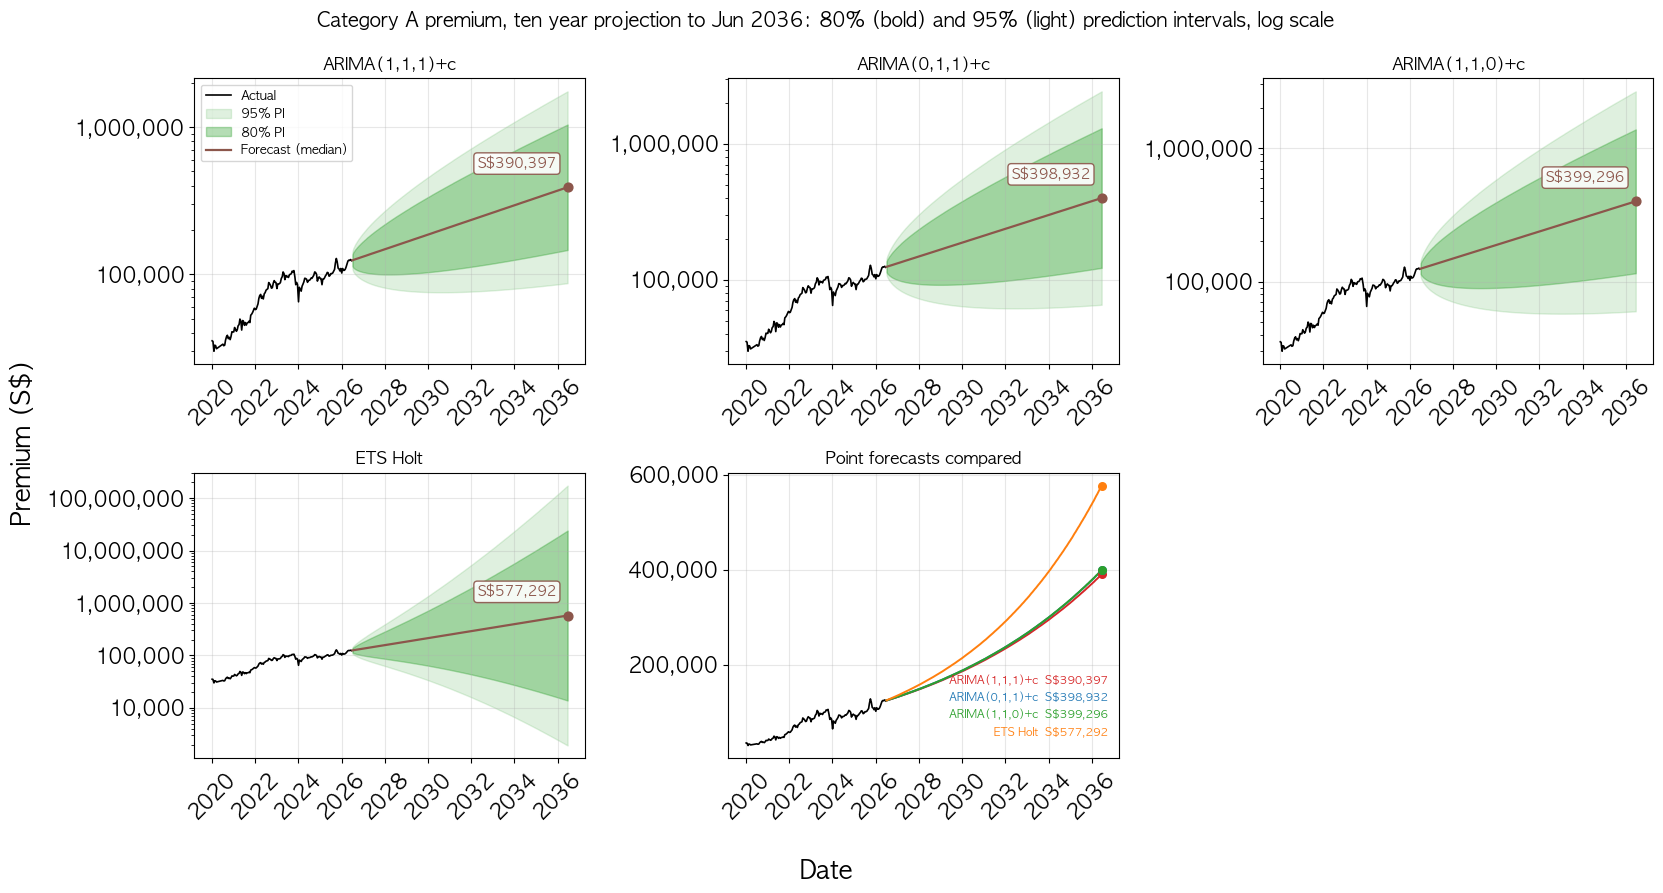

In [37]:
H_LONG = 240                                                  # 24 exercises a year for 10 years
long_specs = [(name, spec) for name, spec in final_specs if spec not in ('DYNREG',)]

_first_month = (full_dates.iloc[-1].to_period('M') + 1).to_timestamp()
long_months  = pd.date_range(_first_month, periods=H_LONG // 2, freq='MS')
future_dates_long = pd.Series([pd.Timestamp(m.year, m.month, d) for m in long_months for d in (3, 17)])
print(f"Long horizon: {H_LONG} exercises, {future_dates_long.iloc[0]:%b %Y} to {future_dates_long.iloc[-1]:%b %Y}")

def forecast_long(spec):
    """Refit on the full sample and project H_LONG exercises. New fits, so new names."""
    if spec == 'ETS':
        long_fit = ETSModel(pd.Series(full_logp), error='add', trend='add').fit(disp=False)
        pr_l = long_fit.get_prediction(start=len(full_logp), end=len(full_logp) + H_LONG - 1)
        f95, f80 = pr_l.summary_frame(alpha=0.05), pr_l.summary_frame(alpha=0.20)
        out_l = (f95['mean'].values, f80['pi_lower'].values, f80['pi_upper'].values,
                 f95['pi_lower'].values, f95['pi_upper'].values)
    else:
        long_fit = ARIMA(full_logp, **spec).fit(method_kwargs={'method': 'nm', 'maxiter': 4000})
        pr_l = long_fit.get_forecast(H_LONG)
        c95, c80 = np.asarray(pr_l.conf_int(alpha=0.05)), np.asarray(pr_l.conf_int(alpha=0.20))
        out_l = (np.asarray(pr_l.predicted_mean), c80[:, 0], c80[:, 1], c95[:, 0], c95[:, 1])
    out_l = [np.exp(np.asarray(v)) for v in out_l]            # premium scale; point path is a median
    assert all(len(v) == H_LONG for v in out_l), "long forecast length does not match H_LONG"
    return out_l

fc_long = {name: forecast_long(spec) for name, spec in long_specs}

long_summary = pd.DataFrame({name: [fc[0][-1], fc[1][-1], fc[2][-1], fc[3][-1], fc[4][-1]]
                             for name, fc in fc_long.items()},
                            index=['median', 'lo80', 'hi80', 'lo95', 'hi95']).T.round(0)
print(f"\nProjection endpoint, {future_dates_long.iloc[-1]:%d %B %Y} (points are medians):")
print(long_summary.to_string())

long_hist = full_dates >= pd.Timestamp('2020-01-01')
fig_long, axes_long = plt.subplots(2, 3, figsize=(17, 9))
axes_long = axes_long.ravel()

for ax_long, (name, spec) in zip(axes_long, long_specs):
    med_l, lo80_l, hi80_l, lo95_l, hi95_l = fc_long[name]
    ax_long.plot(full_dates[long_hist], full_prem[long_hist.values], color='black', lw=1.2, label='Actual')
    ax_long.fill_between(future_dates_long, lo95_l, hi95_l, color='tab:green', alpha=0.15, label='95% PI')
    ax_long.fill_between(future_dates_long, lo80_l, hi80_l, color='tab:green', alpha=0.35, label='80% PI')
    ax_long.plot(future_dates_long, med_l, color='tab:brown', lw=1.6, label='Forecast (median)')
    ax_long.set_yscale('log')                                  # intervals span orders of magnitude at 10 years
    ax_long.set_title(name, fontsize=12)
    ax_long.grid(True, alpha=0.3)
    ax_long.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
    ax_long.tick_params(axis='x', rotation=45)
    ax_long.scatter([future_dates_long.iloc[-1]], [med_l[-1]], color='tab:brown', s=40, zorder=6)
    ax_long.annotate(f"S${med_l[-1]:,.0f}", xy=(future_dates_long.iloc[-1], med_l[-1]),
                     xytext=(-8, 14), textcoords='offset points', ha='right',
                     fontsize=10, fontweight='bold', color='tab:brown',
                     bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='tab:brown', alpha=0.9))
axes_long[0].legend(loc='upper left', fontsize=9)

ax_long_cmp = axes_long[4]
ax_long_cmp.plot(full_dates[long_hist], full_prem[long_hist.values], color='black', lw=1.2, label='Actual')
for (name, spec), colr in zip(long_specs, hz_palette):
    ax_long_cmp.plot(future_dates_long, fc_long[name][0], color=colr, lw=1.4, label=name)
    ax_long_cmp.scatter([future_dates_long.iloc[-1]], [fc_long[name][0][-1]], color=colr, s=30, zorder=6)
long_order = sorted(long_specs, key=lambda s: fc_long[s[0]][0][-1])
for rank, (name, spec) in enumerate(long_order):
    ax_long_cmp.annotate(f"{name}  S${fc_long[name][0][-1]:,.0f}",
                         xy=(0.97, 0.26 - rank * 0.06), xycoords='axes fraction', ha='right',
                         fontsize=8, color=hz_palette[[n for n, _ in long_specs].index(name)])
ax_long_cmp.set_title('Point forecasts compared', fontsize=12)
ax_long_cmp.grid(True, alpha=0.3)
ax_long_cmp.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
ax_long_cmp.tick_params(axis='x', rotation=45)
axes_long[5].axis('off')

fig_long.suptitle(f'Category A premium, ten year projection to {future_dates_long.iloc[-1]:%b %Y}: '
                  '80% (bold) and 95% (light) prediction intervals, log scale', fontsize=14)
fig_long.supxlabel('Date'); fig_long.supylabel('Premium (S$)')
plt.tight_layout()
plt.show()

Spotting more flaws in methodology! Using 16 years of data to forecast the next 10 year proves to be an obvious struggle here, as shown by an unreliably huge prediction interval as well as ETS Holt making a wildly different claim as compared to other arima models, which is something we cannot test. We are doomed if COE reaches 577,292 dollars. There is also a real concern of whether COE trend will forecast using historical growth trend as if COE reaches around 400,000 dollars, so few will actually be able to afford a car. We learn here that quality of data matters a lot. Just because data seems to be available does not mean we can dive immediately into the project as we need to understand the structure of the data, and whether we have sufficient data for it.

### Conclusion

The honest ending is a modest one. The best available forecast of the Category A COE premium is a univariate ARIMA(1,1,1) with drift on the log scale, which amounts to carrying the recent upward tendency forward with rapidly widening uncertainty. Extended ten years, the point paths land around 390,000 dollars, and the 80 percent intervals span from under 146,316 to beyond 1,000,000. For ETS Holt, the interval wided extensively to the point where any rational guess of its 10 years value will surely fall within its interval. This means that the premium trend is highly volatile, and that variance in errors from uncertainty causes a large prediction interval that grows larger for each steps.

The two outside variables this project was built around did not improve its forecasting ability. Resident population turned out to be a spurious level correlation, real looking in levels and gone under differencing, with an insignificant coefficient and worse forecasts when included. Quota has a genuine relationship with the premium, with better AICc performance albeit poorer foreast performance. So, this shows having good model fit does not always translate to forecast performance, and AICc and holdout MASE are both essential tools in evaluating a model.

So our original aim to make a better forecast using exogenous variables is discarded. However, the improved model fit shows that Quota partly explains the dip as explained during model observation, but it does not improve model forecasts to a significant level to go with the idea of forecasting quota to feed premium model. We learn that a seemingly sound economical theory of supply go down price go up, does not translate explicitly to this market where bidding and final price relies more on other variables. Perhaps learning game theory would better assist in modeling the competitive behaviour and therefore the price trend.